In [1]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
from HARK.models import WealthPortfolioConsumerType
from HARK.utilities import get_percentiles
from time import time
from HARK.Calibration.Income.IncomeTools import (
    Cagetti_income,
    parse_income_spec,
    parse_time_params,
)
from HARK.Calibration.life_tables.us_ssa.SSATools import parse_ssa_life_table

mystr = lambda x: "{:.4f}".format(x)

In [2]:
# Define a life-cycle calibration using HARK tools
birth_age = 22
death_age = 110
adjust_infl_to = 1992
income_calib = Cagetti_income["College"]
income_calib["PermShkStd"] = 0.1
income_calib["TranShkStd"] = 0.1

# Income specification
income_params = parse_income_spec(
    age_min=birth_age,
    age_max=death_age,
    adjust_infl_to=adjust_infl_to,
    **income_calib,
)

# Survival and time specification
liv_prb = parse_ssa_life_table(
    female=False, cross_sec=True, year=2004, age_min=birth_age, age_max=death_age
)
time_params = parse_time_params(age_birth=birth_age, age_death=death_age)

# Some custom parameters
my_params = {
    "DiscFac": 0.96,
    "CRRA": 4.5,
    "WealthShift": 0.0,
    "WealthShare": 0.2,
    "AgentCount": 10000,
    "T_sim": 73,
}

# Put it all together into a dictionary
lifecycle_dict = income_params.copy()
lifecycle_dict["LivPrb"] = liv_prb
lifecycle_dict.update(**time_params)
lifecycle_dict.update(**my_params)
lifecycle_dict["Rfree"] = lifecycle_dict["T_cycle"] * [1.03]
lifecycle_dict["T_sim"] = 73

In [3]:
# Make and solve a wealth-in-utility portfolio choice consumer over their life-cycle
MyType = WealthPortfolioConsumerType(**lifecycle_dict)
t0 = time()
MyType.solve()
t1 = time()

print("Solving that model took + " + mystr(t1 - t0) + " seconds.")

Solving that model took + 0.3175 seconds.


In [4]:
# Simulate 10,000 life-cycles, turning off mortality
t0 = time()
MyType.initialize_sym(stop_dead=False)
MyType.symulate()
t1 = time()

print("Simulating 10,000 agents until age 95 took " + mystr(t1 - t0) + " seconds.")

Simulating 10,000 agents until age 95 took 0.9444 seconds.


In [5]:
# Extract simulated history of risky asset share by age
S = MyType.hystory["Share"]

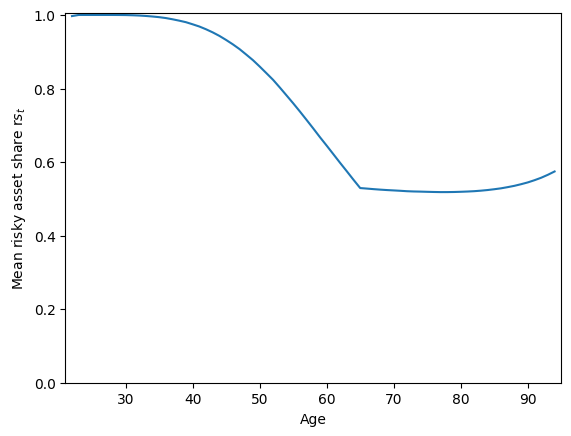

In [6]:
# Plot mean risky asset share by age
age_vec = np.arange(22, 95)
plt.xlim(21, 95)
plt.ylim(0.0, 1.005)
plt.xlabel("Age")
plt.ylabel("Mean risky asset share r$s_t$")
plt.plot(age_vec, np.mean(S, axis=1))
plt.show()

In [7]:
# Extract 10th, 25th, 50th, 75th, and 90th percentiles of risky asset share by age
Share_pctls = np.zeros((73, 5))
for t in range(73):
    Share_pctls[t, :] = get_percentiles(
        S[t, :], percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
    )

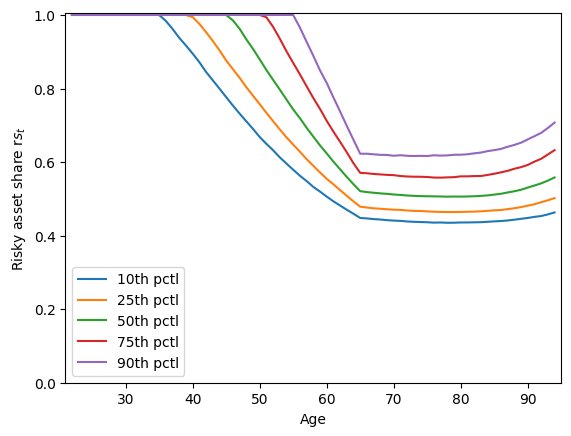

In [8]:
# Plot those percentiles
plt.xlim(21, 95)
plt.ylim(0.0, 1.005)
plt.xlabel("Age")
plt.ylabel("Risky asset share r$s_t$")
plt.plot(age_vec, Share_pctls)
plt.legend(["10th pctl", "25th pctl", "50th pctl", "75th pctl", "90th pctl"], loc=3)
plt.show()